<a href="https://colab.research.google.com/github/Divwardhan/Adversarial_Testing_Framework/blob/main/advancement_mini2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
devdgohil_the_oxfordiiit_pet_dataset_path = kagglehub.dataset_download('devdgohil/the-oxfordiiit-pet-dataset')
indk214_brain_tumor_dataset_segmentation_and_classification_path = kagglehub.dataset_download('indk214/brain-tumor-dataset-segmentation-and-classification')

print('Data source import complete.')


In [ ]:
pip install torchmetrics

In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [ ]:
DATA_DIR = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET"

IMG_DIR = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation/Glioma"
MASK_DIR = "/kaggle/input/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation/Glioma"

IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
print(DEVICE)

In [ ]:
import os
import numpy as np
import torch
import random
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


class TumorDataset(Dataset):
    def __init__(self, root_dir, img_size, augment=False):
        self.root_dir = root_dir
        self.img_size = img_size
        self.augment = augment

        self.images = sorted([
            f for f in os.listdir(root_dir)
            if f.endswith(".png") and not f.endswith("_mask.png")
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        base = img_name.replace(".png", "")
        mask_name = f"{base}_mask.png"

        img_path = os.path.join(self.root_dir, img_name)
        mask_path = os.path.join(self.root_dir, mask_name)

        # Load
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize FIRST (important)
        image = TF.resize(image, (self.img_size, self.img_size))
        mask = TF.resize(mask, (self.img_size, self.img_size), interpolation=InterpolationMode.NEAREST)

        # Convert to tensor
        image = TF.to_tensor(image)
        mask = torch.from_numpy(np.array(mask)).float()

        # Binarize mask
        mask = (mask > 128).float().unsqueeze(0)

        # =========================
        # AUGMENTATIONS
        # =========================
        if self.augment:

            # 🔁 Flip
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            # 🔄 Rotation (safe angles)
            angle = random.choice([0, 90, 180, 270])
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

            # 🌗 Intensity (image only)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, random.uniform(0.85, 1.15))
                image = TF.adjust_contrast(image, random.uniform(0.85, 1.15))

            # 🎨 Color tint (image only)
            if random.random() > 0.5:
                image = TF.adjust_saturation(image, random.uniform(0.9, 1.1))
                image = TF.adjust_hue(image, random.uniform(-0.05, 0.05))

        return image, mask

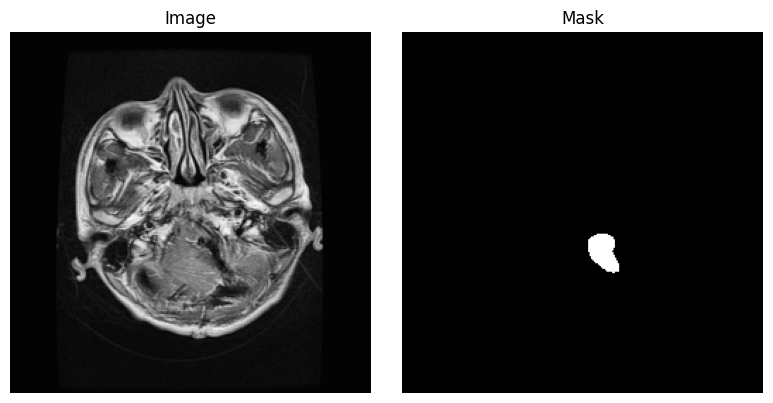

torch.Size([1, 256, 256])
tensor([0., 1.])


In [146]:
# create dataset
dataset = TumorDataset(
    root_dir=f"{DATA_DIR}/Segmentation/Glioma",  # path to your folder
    img_size=IMG_SIZE
)

# get one sample
img, mask = dataset[10]

# visualize
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img.permute(1,2,0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask[0], cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

print(mask.shape)
print(mask.unique())


Unique values: [  3 255]


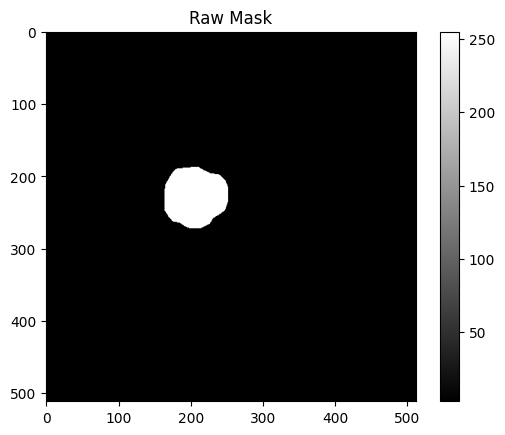

In [147]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

mask_path = f"{DATA_DIR}/Segmentation/Glioma/enh_1841_mask.png"  # example
raw = Image.open(mask_path).convert("L")
arr = np.array(raw)

print("Unique values:", np.unique(arr))
plt.imshow(arr, cmap="gray")
plt.colorbar()
plt.title("Raw Mask")
plt.show()


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)


In [ ]:
class nnUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # nnU-Net uses LeakyReLU and InstanceNorm for better medical image stability
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.InstanceNorm2d(out_c),
                nn.LeakyReLU(negative_slope=0.01, inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.InstanceNorm2d(out_c),
                nn.LeakyReLU(negative_slope=0.01, inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(in_channels, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 128)
        self.enc4 = conv_block(128, 256)
        self.bottleneck = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2, 2)

        # Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = conv_block(64, 32)

        # Deep Supervision Heads (Optional but highly recommended for high Dice)
        self.ds4 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.ds3 = nn.Conv2d(128, num_classes, kernel_size=1)
        self.ds2 = nn.Conv2d(64, num_classes, kernel_size=1)
        self.final_out = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x, deep_supervision=False):
        # Encoder path
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))

        # Bottleneck
        b = self.bottleneck(self.pool(s4))

        # Decoder path with concat
        d4 = self.up4(b)
        d4 = torch.cat([d4, s4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, s3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)

        if deep_supervision and self.training:
            return [
                self.final_out(d1),
                self.ds2(d2),
                self.ds3(d3),
                self.ds4(d4)
            ]

        return self.final_out(d1)

In [ ]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


In [ ]:
model = nnUNet(in_channels=3, num_classes=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0])).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [ ]:
img, mask = dataset[0]
print(mask.sum().item(), mask.numel())


In [ ]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

# 1. Use BCE for individual tumor datasets
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0])).to(DEVICE)
scaler = GradScaler()
best_val_dice = 0.0

for epoch in range(EPOCHS):
    # =========================
    # TRAIN
    # =========================
    model.train()
    train_loss, train_dice = 0.0, 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        # Binary Consistency: Ensure mask is [Batch, 1, H, W] and Float
        if masks.ndim == 3:
            masks = masks.unsqueeze(1)
        masks = masks.float()

        optimizer.zero_grad()

        with autocast():
            # Deep supervision: list of [B, 1, H_res, W_res]
            outputs = model(imgs, deep_supervision=True)

            # nnU-Net weighting for the 5 levels (Bottleneck + 4 Decoder levels)
            weights = [1.0, 0.5, 0.25, 0.125, 0.0625]
            total_loss = 0

            for i, output in enumerate(outputs):
                # Interpolate mask to match the decoder level resolution
                target_scaled = F.interpolate(masks, size=output.shape[2:], mode='nearest')

                # Binary Loss + Dice Loss
                loss_bce = criterion(output, target_scaled)
                loss_dice = dice_loss(output, target_scaled) # Ensure your dice_loss supports binary

                total_loss += weights[i] * (loss_bce + loss_dice)

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += total_loss.item()

        # Metric calculation on the final high-res output
        with torch.no_grad():
            preds = (torch.sigmoid(outputs[0]) > 0.5).float()
            intersection = (preds * masks).sum()
            union = preds.sum() + masks.sum()
            train_dice += (2. * intersection / (union + 1e-8)).item()

    scheduler.step()

    # =========================
    # VALIDATION
    # =========================
    model.eval()
    val_loss, val_dice = 0.0, 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            if masks.ndim == 3: masks = masks.unsqueeze(1)
            masks = masks.float()

            # Deep supervision is OFF during validation/inference
            logits = model(imgs, deep_supervision=False)

            v_loss = criterion(logits, masks)
            v_dice_loss = dice_loss(logits, masks)
            val_loss += (v_loss + v_dice_loss).item()

            # Validation Dice
            preds = (torch.sigmoid(logits) > 0.5).float()
            inter = (preds * masks).sum()
            uni = preds.sum() + masks.sum()
            val_dice += (2. * inter / (uni + 1e-8)).item()

    # Average metrics
    train_loss /= len(train_loader); train_dice /= len(train_loader)
    val_loss /= len(val_loader); val_dice /= len(val_loader)

    # Save Best Model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({'model_state_dict': model.state_dict(), 'dice': val_dice}, "best_nnunet.pth")

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f}")

/tmp/ipykernel_699/3512253448.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_699/3512253448.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 | Train Loss: 3.1695 | Val Dice: 0.0506
Epoch 2 | Train Loss: 2.8925 | Val Dice: 0.1262
Epoch 3 | Train Loss: 2.7146 | Val Dice: 0.2321
Epoch 4 | Train Loss: 2.6090 | Val Dice: 0.3353
Epoch 5 | Train Loss: 2.5204 | Val Dice: 0.4262
Epoch 6 | Train Loss: 2.4564 | Val Dice: 0.4593
Epoch 7 | Train Loss: 2.4027 | Val Dice: 0.5136
Epoch 8 | Train Loss: 2.3595 | Val Dice: 0.5340


In [ ]:
pred_prob = torch.sigmoid(logits)
pred_bin = (pred_prob > 0.5).float()


In [ ]:
print(
    pred_prob.min().item(),
    pred_prob.max().item(),
    pred_prob.mean().item()
)


In [ ]:
model.eval()
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    logits = model(imgs)
    probs = torch.sigmoid(logits)              # convert to probability
    preds = (probs > 0.7).float()              # threshold → SHARP mask

plt.figure(figsize=(12,4))
for i in range(3):
    # image
    plt.subplot(3,3,3*i+1)
    plt.imshow(imgs[i].cpu().permute(1,2,0))
    plt.axis("off")

    # ground truth
    plt.subplot(3,3,3*i+2)
    plt.imshow(masks[i][0].cpu(), cmap="gray")
    plt.axis("off")

    # prediction (SHARP)
    plt.subplot(3,3,3*i+3)
    plt.imshow(preds[i][0].cpu(), cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
torch.save(model.state_dict(), "unet_pet_segmentation.pth")


In [ ]:
model.eval()
for p in model.parameters():
    p.requires_grad = False


In [ ]:
def soft_iou(pred, target, eps=1e-6):
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) - intersection
    return (intersection + eps) / (union + eps)


In [ ]:
iou_fail = 1 - soft_iou(preds, masks).mean()


In [ ]:
sobel_x = torch.tensor(
    [[1, 0, -1],
     [2, 0, -2],
     [1, 0, -1]],
    dtype=torch.float32,
    device=DEVICE
).view(1, 1, 3, 3)

sobel_y = sobel_x.transpose(2, 3)

def edge_map(x):
    gx = F.conv2d(x, sobel_x, padding=1)
    gy = F.conv2d(x, sobel_y, padding=1)
    return torch.sqrt(gx**2 + gy**2 + 1e-6)


In [ ]:
import torch.nn.functional as F

boundary_fail = F.l1_loss(edge_map(preds), edge_map(masks))


In [ ]:
FAILURE_SCORE = (
    1.0 * iou_fail +
    0.5 * boundary_fail
)




In [ ]:
def get_edges(x):
    """Simple Laplacian-based edge detection."""
    laplacian_kernel = torch.tensor([[-1, -1, -1],
                                     [-1,  8, -1],
                                     [-1, -1, -1]], dtype=torch.float32, device=x.device).view(1, 1, 3, 3)
    # Convert 3-channel input to 1-channel grayscale by taking the mean
    if x.shape[1] == 3:
        x = x.mean(dim=1, keepdim=True)
    # Assume x is [B, 1, H, W]
    return F.conv2d(x, laplacian_kernel, padding=1).abs()

In [ ]:
def get_adversarial_loss(logits, targets):
    """
    Maximizing BCE is more effective than minimizing IoU alone.
    It forces the model to be 'confidently wrong'.
    """
    return F.binary_cross_entropy_with_logits(logits, targets)

def get_iou_failure(preds, targets):
    """
    Using -log(IoU) ensures that as IoU gets smaller,
    the loss gets exponentially larger, pushing for total failure.
    """
    iou = soft_iou(preds, targets).mean()
    return -torch.log(iou + 1e-7)

In [ ]:
class StressGenerator(nn.Module):
    def __init__(self, eps=0.05):
        super().__init__()
        self.eps = eps

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True) # Leaky ReLU helps gradient flow
            )

        self.enc1 = block(3, 32)
        self.enc2 = block(32, 64)
        self.enc3 = block(64, 128)
        self.pool = nn.MaxPool2d(2) # MaxPool preserves sharp features (edges) better than AvgPool

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = block(128 + 64, 64)
        self.dec1 = block(64 + 32, 32)
        self.out = nn.Conv2d(32, 3, kernel_size=1)

    def forward(self, img):
        # UNet style forward pass
        x1 = self.enc1(img)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))

        x = self.up(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        # Tanh ensures delta is [-1, 1], multiplied by eps gives strict budget control
        delta = torch.tanh(self.out(x))
        return torch.clamp(img + self.eps * delta, 0, 1)


In [ ]:
stress_gen = StressGenerator().to(DEVICE)
optimizer_g = torch.optim.Adam(stress_gen.parameters(), lr=1e-4)


In [ ]:
STRESS_EPOCHS = 15

In [ ]:
import time

LOG_EVERY = 20   # batches
start_time = time.time()


In [ ]:
import torch
import torch.nn.functional as F
from torchmetrics.functional import structural_similarity_index_measure as ssim

# --- Tunable Hyperparameters ---
# Attack Weights (Scale these up to break the model harder)
W_IOU = 2.0      # Importance of dropping the IoU score
W_BCE = 1.0      # Importance of making the model 'confidently wrong'
W_EDGE = 0.8     # Importance of distorting object boundaries

# Realism Weights (Scale these up to make perturbations invisible)
W_L2 = 0.1       # Penalty for raw pixel changes
W_SSIM = 1.5     # Penalty for structural/texture changes (the 'Human Eye' check)

for epoch in range(STRESS_EPOCHS):
    for batch_idx, (imgs, masks) in enumerate(train_loader):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        # 1. Generate & Predict
        stressed_imgs = stress_gen(imgs)
        logits = model(stressed_imgs)
        preds = torch.sigmoid(logits)

        # 2. SEPARATE LOSS COMPONENTS

        # Attack Logic: We want to maximize these (negative sign in final loss)
        iou_f = get_iou_failure(preds, masks)           # Use the Hard Dice Loss logic here
        bce_f = F.binary_cross_entropy_with_logits(logits, masks)
        edge_f = F.mse_loss(edge_map(preds), edge_map(masks))

        total_failure = (W_IOU * iou_f) + (W_BCE * bce_f) + (W_EDGE * edge_f)

        # Realism Logic: We want to minimize these
        l2_dist = F.mse_loss(stressed_imgs, imgs)
        # 1 - SSIM is the 'Structural Loss'
        ssim_dist = 1 - ssim(stressed_imgs, imgs)

        total_realism_cost = (W_L2 * l2_dist) + (W_SSIM * ssim_dist)

        # 3. COMBINED LOSS
        # Minimizing -Failure is the same as Maximizing Failure
        loss = -total_failure + total_realism_cost

        # 4. Optimization
        optimizer_g.zero_grad()
        loss.backward()
        optimizer_g.step()

        # ---------------- LOGGING ----------------
        if global_step % LOG_EVERY == 0:
            # Monitor the "Efficiency" of the attack
            # High efficiency = High Failure with Low Realism Cost
            efficiency = total_failure.item() / (total_realism_cost.item() + 1e-6)

            print(f"Step {global_step} | Loss: {loss.item():.4f}")
            print(f"  > Failure Score: {total_failure.item():.2f} (IoU: {iou_f.item():.3f})")
            print(f"  > Realism Cost: {total_realism_cost.item():.2f} (SSIM: {1-ssim_dist.item():.3f})")
            print(f"  > Attack Efficiency: {efficiency:.2f}")

        global_step += 1




In [ ]:
import random
import matplotlib.pyplot as plt
from torchmetrics.functional import structural_similarity_index_measure as ssim

def visualize_failure(imgs, masks, model, stress_gen):
    model.eval()
    stress_gen.eval()

    # choose random index
    idx = random.randint(0, imgs.size(0) - 1)

    img = imgs[idx:idx+1]
    mask = masks[idx:idx+1]

    with torch.no_grad():
        stressed = stress_gen(img).clamp(0, 1)
        pred_clean = model(img)
        pred_stress = model(stressed)

    img_np = img[0].cpu().permute(1,2,0)
    stressed_np = stressed[0].cpu().permute(1,2,0)
    perturb_np = (stressed - img).abs().mean(dim=1)[0].cpu()
    clean_pred_np = torch.sigmoid(pred_clean)[0,0].cpu()
    stress_pred_np = torch.sigmoid(pred_stress)[0,0].cpu()
    edges_clean = get_edges(img)
    edges_stress = get_edges(stressed)

    edge_diff = (edges_clean - edges_stress).abs()[0,0].cpu()

    ssim_map = ssim(
        img,
        stressed,
        data_range=1.0,
        return_full_image=True
    )[1]  # [0] is score, [1] is map
    ssim_map_np = ssim_map[0].mean(dim=0).cpu()
    # mean over channels → H x W

    mask_np = mask[0,0].cpu()

    plt.figure(figsize=(15,6))

    plt.subplot(2,4,1)
    plt.title("Original Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(2,4,2)
    plt.title("Stressed Image")
    plt.imshow(stressed_np)
    plt.axis("off")

    plt.subplot(2,4,3)
    plt.title("Perturbation Map")
    plt.imshow(perturb_np, cmap="hot")
    plt.axis("off")

    plt.subplot(2,4,4)
    plt.title("Ground Truth Mask")
    plt.imshow(mask_np, cmap="gray")
    plt.axis("off")

    plt.subplot(2,4,5)
    plt.title("Clean Prediction")
    plt.imshow(clean_pred_np>0.75, cmap="gray", vmin=0, vmax=1)
    plt.axis("off")

    plt.subplot(2,4,6)
    plt.title("Stressed Prediction")
    plt.imshow(stress_pred_np>0.75, cmap="gray")
    plt.axis("off")

    plt.subplot(2,4,7)
    plt.title("Edge Difference")
    plt.imshow(edge_diff, cmap="gray")
    plt.axis("off")

    plt.subplot(2,4,8)
    plt.title("SSIM Map")
    plt.imshow(ssim_map_np, cmap="gray")
    plt.colorbar()
    plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
imgs, masks = next(iter(val_loader))
imgs = imgs.to(DEVICE)
masks = masks.to(DEVICE)

visualize_failure(imgs, masks, model, stress_gen)
